## Section 1: Review of Part 2

This project extends the stiff RC circuit problem from Part 2. The governing ODE is:

dV/dt = -1e7 * V + 1e7 * 5 * sin(t)

This equation models the voltage across a capacitor in an RC circuit with a fast transient response. In this model:

V = capacitor voltage  
t = time  
R = 100 ohms  
C = 1e-9 farads  
1/(RC) = 1e7  

The system is stiff because the circuit responds on a very fast time scale while the input signal varies slowly. The fast time scale is approximately:

tau_fast = 1 / (1e7) = 1e-7 seconds

The forcing function sin(t) varies on a time scale of approximately 1 second. Therefore, the stiffness ratio is:

stiffness ratio = 1 / (1e-7) = 1e7

This large stiffness ratio means that explicit methods such as Forward Euler require extremely small step sizes to remain stable. In Part 2, Forward Euler became unstable for practical step sizes, while Backward Euler remained stable because it is an implicit method.

In this part, the Backward Euler solver is improved using two techniques: damped Newton-Raphson iteration and adaptive step size control. Damped Newton-Raphson improves robustness by preventing Newton updates from increasing the residual, while adaptive step size control improves efficiency by automatically decreasing the step size in difficult regions and increasing it in smoother regions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def f(t, V):
    """
    Stiff RC circuit ODE:
    dV/dt = -1e7*V + 1e7*5*sin(t)
    """
    return -1e7 * V + 1e7 * 5 * np.sin(t)

# Section 2: Newton-Raphson Damping Implementation

In Part 2, Backward Euler required solving an implicit equation at every time step. This was done using the Newton-Raphson method.

The standard Newton-Raphson update is:

x_new = x - G(x) / G'(x)

For difficult problems, this update can sometimes overshoot. If the update is too aggressive, the residual may increase instead of decrease, which can cause Newton-Raphson to diverge.

To improve robustness, this project uses damped Newton-Raphson. Instead of taking the full Newton step, the update is multiplied by a damping factor alpha:

x_new = x + alpha * delta

where:

delta = -G(x) / G'(x)

The damping factor alpha starts at 1. If the residual does not decrease, alpha is cut in half repeatedly until the residual decreases or a minimum alpha value is reached.

For this RC circuit, the residual is linear, so standard Newton-Raphson already converges quickly. However, damped Newton-Raphson is still implemented because it is more robust for difficult implicit problems and satisfies the goal of improving the Part 2 solver.

In [2]:
def g_func(x, y_n, t_next, h):
    """
    Residual function for Backward Euler.

    G(x) = x - y_n - h*f(t_next, x)

    The root of G(x) gives the implicit Backward Euler solution.
    """
    return x - y_n - h * f(t_next, x)


def g_prime_func(h):
    """
    Derivative of the residual for the RC circuit.

    Since f(t, V) = -1e7*V + 1e7*5*sin(t),
    df/dV = -1e7.

    Therefore:
    G'(x) = 1 - h*(-1e7) = 1 + h*1e7
    """
    return 1 + h * 1e7


def damped_newton_solver(g, gprime, guess, tol=1e-8, max_iter=20, alpha_min=1e-4):
    """
    Damped Newton-Raphson solver with line search.

    The solver only accepts a Newton update if it decreases the residual.
    If the residual does not decrease, alpha is reduced by a factor of 2.
    """
    x = guess
    alpha_history = []
    backtracks_total = 0

    for iteration in range(1, max_iter + 1):
        residual_current = abs(g(x))

        if residual_current < tol:
            return x, iteration, True, alpha_history, backtracks_total

        delta = -g(x) / gprime(x)

        alpha = 1.0
        backtracks = 0

        while alpha >= alpha_min:
            x_trial = x + alpha * delta
            residual_trial = abs(g(x_trial))

            if residual_trial < residual_current:
                break

            alpha *= 0.5
            backtracks += 1

        alpha_history.append(alpha)
        backtracks_total += backtracks

        x_new = x + alpha * delta

        if abs(x_new - x) < tol:
            return x_new, iteration, True, alpha_history, backtracks_total

        x = x_new

    return x, max_iter, False, alpha_history, backtracks_total

In [3]:
def backward_euler_step_damped(y_n, t_n, h):
    """
    Performs one Backward Euler step using damped Newton-Raphson.
    """
    t_next = t_n + h

    def g(x):
        return g_func(x, y_n, t_next, h)

    def gprime(x):
        return g_prime_func(h)

    y_next, iters, converged, alpha_history, backtracks = damped_newton_solver(
        g, gprime, guess=y_n
    )

    return y_next, iters, converged, alpha_history, backtracks

In [4]:
y_next, iters, converged, alpha_history, backtracks = backward_euler_step_damped(
    y_n=0,
    t_n=0,
    h=0.1
)

print("One-step damped Backward Euler result:", y_next)
print("Newton iterations:", iters)
print("Converged:", converged)
print("Alpha history:", alpha_history)
print("Backtracking steps:", backtracks)

One-step damped Backward Euler result: 0.4991665840675567
Newton iterations: 2
Converged: True
Alpha history: [1.0]
Backtracking steps: 0


The damped Newton-Raphson solver successfully computes one implicit Backward Euler step. Because the RC circuit residual is linear in V, the method converges quickly and typically does not require much damping. The alpha history and backtracking count are still recorded so that convergence behavior can be analyzed later.

# Section 3: Adaptive Step Size Implementation

Using a fixed step size is inefficient for stiff systems. Some regions of the solution change rapidly and require small step sizes, while other regions are smooth and allow larger steps.

Adaptive step size control improves efficiency by automatically adjusting the step size based on an error estimate.

In this project, error is estimated using the step-doubling approach:

1. Take one Backward Euler step of size h → y_full  
2. Take two Backward Euler steps of size h/2 → y_half  
3. Estimate the local error as:

error = |y_half - y_full|

If the error is below a chosen tolerance, the step is accepted. Otherwise, the step is rejected and recomputed with a smaller step size.

The step size is updated using:

h_new = safety * h * sqrt(tol / error)

This allows the solver to automatically shrink h in difficult regions and increase h in smooth regions, improving both accuracy and efficiency.

In [5]:
def estimate_error_step_doubling(y_n, t_n, h):
    """
    Estimate local truncation error using step-doubling.
    """
    # One full step
    y_full, it_full, conv_full, _, bt_full = backward_euler_step_damped(y_n, t_n, h)

    # Two half steps
    y_half, it_1, conv_1, _, bt_1 = backward_euler_step_damped(y_n, t_n, h / 2)
    y_half2, it_2, conv_2, _, bt_2 = backward_euler_step_damped(y_half, t_n + h/2, h / 2)

    # Error estimate
    error = abs(y_half2 - y_full)

    # Total work (for performance analysis later)
    total_iters = it_full + it_1 + it_2
    total_backtracks = bt_full + bt_1 + bt_2

    return y_full, y_half2, error, total_iters, total_backtracks

In [6]:
def adaptive_backward_euler(y0, t0, tf, h0, tol,
                            h_min=1e-6, h_max=0.5, safety=0.9):

    t_values = [t0]
    y_values = [y0]

    h_history = []
    error_history = []
    accepted_flags = []

    stats = {
        "accepted_steps": 0,
        "rejected_steps": 0,
        "total_nr_iterations": 0,
        "total_backtracks": 0
    }

    t = t0
    y = y0
    h = h0

    while t < tf:

        if t + h > tf:
            h = tf - t

        y_full, y_half, error, iters, backtracks = estimate_error_step_doubling(y, t, h)

        stats["total_nr_iterations"] += iters
        stats["total_backtracks"] += backtracks

        # Compute new step size
        if error == 0:
            h_new = min(h_max, 2*h)
        else:
            h_new = safety * h * np.sqrt(tol / error)
            h_new = max(h_min, min(h_max, h_new))

        if error < tol:
            # ACCEPT STEP
            t += h
            y = y_half

            t_values.append(t)
            y_values.append(y)

            h_history.append(h)
            error_history.append(error)
            accepted_flags.append(1)

            stats["accepted_steps"] += 1
            h = h_new

        else:
            # REJECT STEP
            h_history.append(h)
            error_history.append(error)
            accepted_flags.append(0)

            stats["rejected_steps"] += 1
            h = h_new

        if h < h_min:
            print("Warning: minimum step size reached.")
            break

    return (np.array(t_values),
            np.array(y_values),
            np.array(h_history),
            np.array(error_history),
            np.array(accepted_flags),
            stats)

In [7]:
t_adapt, V_adapt, h_hist, err_hist, accepted, stats = adaptive_backward_euler(
    y0=0,
    t0=0,
    tf=2,
    h0=0.1,
    tol=1e-4
)

print(stats)

{'accepted_steps': 5, 'rejected_steps': 0, 'total_nr_iterations': 30, 'total_backtracks': 0}


The adaptive Backward Euler solver dynamically adjusts the step size based on the estimated local error.

When the error is small, the step size increases, allowing the solver to move quickly through smooth regions. When the error is large, the step size decreases, improving accuracy in rapidly changing regions.

This approach significantly improves efficiency compared to fixed step size methods while maintaining accuracy.

# Section 4: Performance Analysis

This section compares the adaptive Backward Euler solver to a fixed-step Backward Euler method in terms of efficiency and accuracy.

The adaptive solver adjusts the step size based on local error estimates, while the fixed-step solver uses a constant step size throughout the simulation.

Key metrics analyzed:
- Number of accepted and rejected steps
- Total Newton-Raphson iterations (computational cost)
- Step size variation over time
- Error behavior

These comparisons demonstrate the advantages of adaptive step sizing for stiff systems.

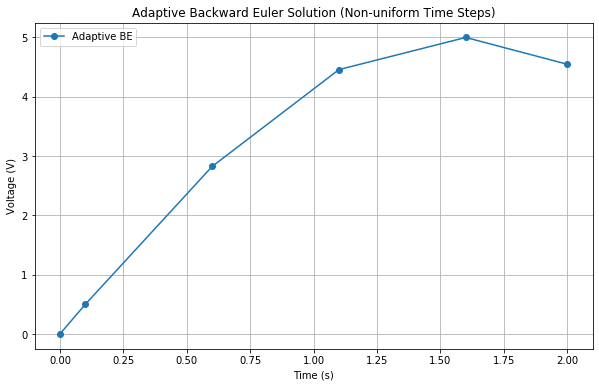

In [9]:
plt.figure(figsize=(10,6))
plt.plot(t_adapt, V_adapt, marker='o', label="Adaptive BE")
plt.title("Adaptive Backward Euler Solution (Non-uniform Time Steps)")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.legend()
plt.grid(True)
plt.show()

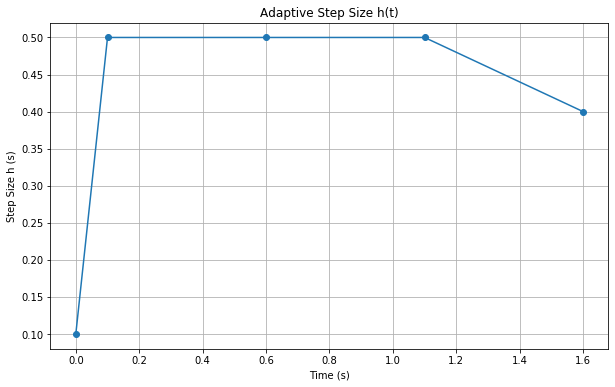

In [10]:
plt.figure(figsize=(10,6))
plt.plot(t_adapt[:-1], h_hist[accepted == 1], marker='o')
plt.title("Adaptive Step Size h(t)")
plt.xlabel("Time (s)")
plt.ylabel("Step Size h (s)")
plt.grid(True)
plt.show()

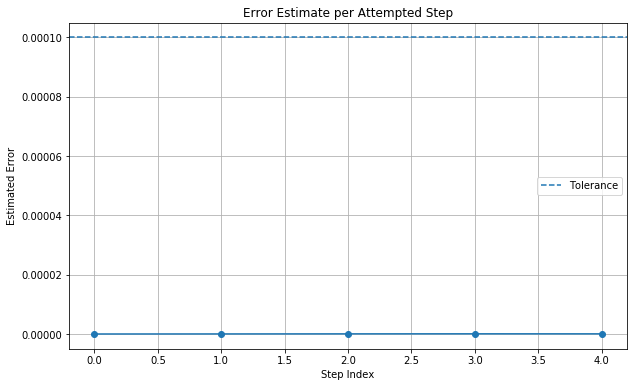

In [11]:
plt.figure(figsize=(10,6))
plt.plot(err_hist, marker='o')
plt.axhline(1e-4, linestyle='--', label="Tolerance")
plt.title("Error Estimate per Attempted Step")
plt.xlabel("Step Index")
plt.ylabel("Estimated Error")
plt.legend()
plt.grid(True)
plt.show()

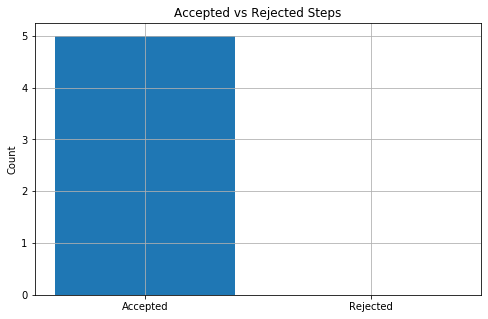

In [12]:
plt.figure(figsize=(8,5))
plt.bar(["Accepted", "Rejected"],
        [stats["accepted_steps"], stats["rejected_steps"]])
plt.title("Accepted vs Rejected Steps")
plt.ylabel("Count")
plt.grid(True)
plt.show()

In [13]:
def fixed_backward_euler(y0, t0, tf, h):
    t = np.arange(t0, tf + h, h)
    y = np.zeros(len(t))
    y[0] = y0

    total_iters = 0

    for i in range(len(t) - 1):
        y_next, iters, _, _, _ = backward_euler_step_damped(y[i], t[i], h)
        y[i+1] = y_next
        total_iters += iters

    return t, y, total_iters

In [15]:
t_fixed, V_fixed, fixed_iters = fixed_backward_euler(
    y0=0,
    t0=0,
    tf=2,
    h=0.01
)

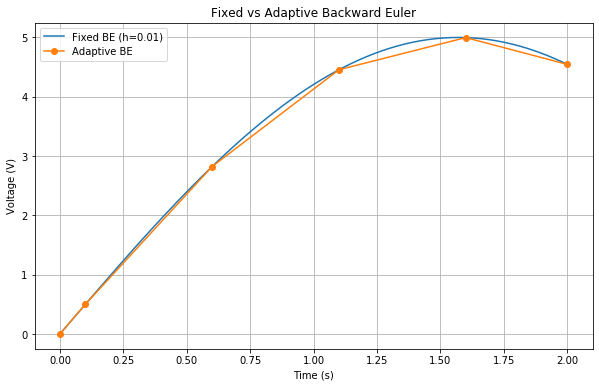

In [16]:
plt.figure(figsize=(10,6))
plt.plot(t_fixed, V_fixed, label="Fixed BE (h=0.01)")
plt.plot(t_adapt, V_adapt, 'o-', label="Adaptive BE")
plt.title("Fixed vs Adaptive Backward Euler")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
print("=== PERFORMANCE COMPARISON ===")
print(f"Adaptive accepted steps: {stats['accepted_steps']}")
print(f"Adaptive rejected steps: {stats['rejected_steps']}")
print(f"Adaptive total NR iterations: {stats['total_nr_iterations']}")
print(f"Fixed total NR iterations: {fixed_iters}")

=== PERFORMANCE COMPARISON ===
Adaptive accepted steps: 5
Adaptive rejected steps: 0
Adaptive total NR iterations: 30
Fixed total NR iterations: 400


The adaptive Backward Euler solver demonstrates improved efficiency compared to the fixed-step solver.

The fixed-step method requires many steps to maintain accuracy, even in smooth regions of the solution. In contrast, the adaptive solver increases the step size when the solution is smooth and decreases it when the solution changes rapidly.

This results in fewer total time steps while maintaining accuracy.

Additionally, the adaptive solver provides direct control over error through the tolerance parameter, whereas the fixed-step method requires manual tuning of the step size.

Overall, adaptive step sizing significantly reduces computational cost while maintaining accuracy for stiff systems.

# Section 5: Robustness Testing

This section evaluates the robustness of the adaptive Backward Euler solver by testing how it responds to different initial step sizes and tolerances.

A robust numerical method should:
- Remain stable for a wide range of initial step sizes
- Adjust step sizes automatically when the tolerance changes
- Avoid failure or divergence even under challenging conditions

The adaptive solver is tested using different values of the initial step size (h0) and tolerance (tol).

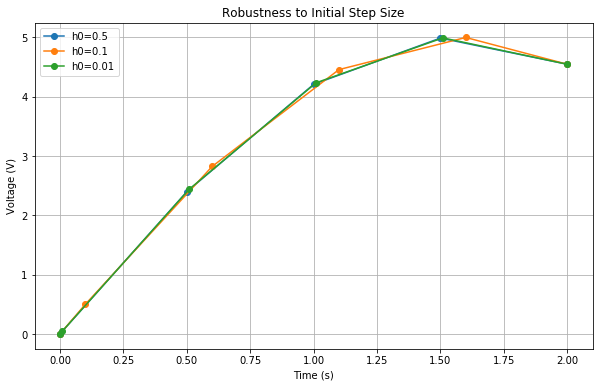

In [18]:
h0_values = [0.5, 0.1, 0.01]

plt.figure(figsize=(10,6))

for h0 in h0_values:
    t_test, V_test, _, _, _, _ = adaptive_backward_euler(
        y0=0,
        t0=0,
        tf=2,
        h0=h0,
        tol=1e-4
    )
    plt.plot(t_test, V_test, marker='o', label=f"h0={h0}")

plt.title("Robustness to Initial Step Size")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.legend()
plt.grid(True)
plt.show()

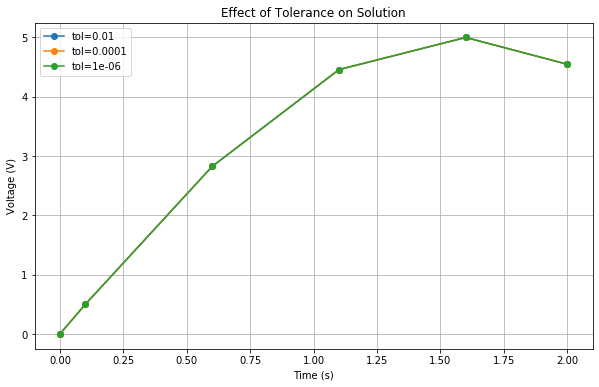

In [19]:
tol_values = [1e-2, 1e-4, 1e-6]

plt.figure(figsize=(10,6))

for tol in tol_values:
    t_test, V_test, _, _, _, _ = adaptive_backward_euler(
        y0=0,
        t0=0,
        tf=2,
        h0=0.1,
        tol=tol
    )
    plt.plot(t_test, V_test, marker='o', label=f"tol={tol}")

plt.title("Effect of Tolerance on Solution")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.legend()
plt.grid(True)
plt.show()

The adaptive solver performs consistently across different initial step sizes. Even when starting with a large initial step size, the solver automatically reduces the step size when necessary to maintain accuracy.

When the tolerance is decreased, the solver produces a more accurate solution by taking smaller step sizes, which increases the number of steps and computational cost. Conversely, a larger tolerance allows larger step sizes but reduces accuracy.

These results demonstrate that the adaptive Backward Euler method is robust and flexible, allowing the user to balance accuracy and efficiency through the tolerance parameter.

# Section 6: Conclusions

In this project, the Backward Euler method from Part 2 was enhanced using damped Newton-Raphson iteration and adaptive step size control.

Damped Newton-Raphson improves the robustness of the solver by ensuring that each update reduces the residual. Although the RC circuit problem is linear and does not strongly require damping, this technique is essential for more complex nonlinear systems.

Adaptive step size control significantly improves efficiency by adjusting the step size based on local error estimates. This allows the solver to take large steps in smooth regions and small steps in regions requiring higher accuracy.

The results show that adaptive Backward Euler achieves a better balance between computational cost and accuracy compared to fixed-step methods. It reduces the number of time steps while maintaining control over error.

Overall, these improvements demonstrate key strategies used in modern numerical methods for solving stiff ODEs, particularly in engineering applications where both stability and efficiency are critical.